# QCS Measurement Time Analysis

## QCS Program

In [6]:
"""QCS execution measurement program"""
import keysight.qcs as qcs
import numpy as np
import time

ns = 1e-9
us = 1e-6
MHz = 1e6

program = qcs.Program()
mapper = qcs.ChannelMapper()
step_duration = qcs.Scalar(
    name = "step_duration",
    value = 20 * us,
    dtype = float
)
acq_duration = qcs.Scalar(
    name = "acq_duration",
    value = 2 * us,
    dtype = float
)

awg_channels = qcs.Channels(
    labels = range(4),
    name = "awg_channels",
)
dig_channels = qcs.Channels(
    labels = range(4),
    name = "dig_channels",
)

mapper.add_channel_mapping(
    awg_channels,
    [
        (1,4,1), (1,4,2), (1,4,3), (1,4,4)
    ],
    instrument_types = qcs.InstrumentEnum.M5300AWG,
)
mapper.add_channel_mapping(
    dig_channels,
    [
        (1,18,1), (1,18,2), (1,18,3), (1,18,4)
    ],
    instrument_types = qcs.InstrumentEnum.M5200Digitizer
)
mapper.set_lo_frequencies(
    (1,4,4),
    lo_frequency=0
)

program.add_waveform(
    pulse = qcs.RFWaveform(
        duration = step_duration,
        envelope = qcs.GaussianEnvelope(),
        amplitude = 1.0,
        rf_frequency = 540 * MHz
    ),
    channels = awg_channels[3],
)
program.add_acquisition(
    integration_filter = qcs.RFWaveform(
        duration = acq_duration,
        envelope = qcs.GaussianEnvelope(),
        amplitude= 1.0,
        rf_frequency= 540 * MHz
    ),
    channels = dig_channels[3]
)

program.n_shots(10000)

backend = qcs.HclBackend(
    channel_mapper=mapper,
    hw_demod = True,
    init_time = 60 * ns,
    keep_progress_bar = False
)



In [4]:
print(dir(program.variables))

['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_cs_types', '_formatted_properties', '_from_cs', '_impl', '_joined_properties', '_post_serialization', '_serializable_state', '_set_attributes', '_slots', '_subclasses', 'acq_duration', 'declare', 'reference_equals', 'remove', 'step_duration', 'variables']


## Execution

In [25]:
NUM_AVG = 10
# acq_time = np.logspace(np.log10(0.1 * us), np.log10(10 * us), 10)
# step_time = np.logspace(np.log10(0.1 * us), np.log10(100 * us), 10)

acq_time = np.linspace(0.1 * us, 5 * us, 20)
step_time = np.linspace(0.1 * us, 5 * us, 20)

initial_data = {}
average_data = {}

for m in acq_time:
    for s in step_time:
        t = []
        for i in range(NUM_AVG):
            program.variables.acq_duration.value = m
            program.variables.step_duration.value = s
            start_time = time.time()
            try:
                _ = qcs.Executor(backend).execute(program)
                end_time = time.time()

                if i != 0:
                    t.append(end_time-start_time)
                initial_data[(m,s)] = end_time-start_time
            except:
                initial_data[(m,s)] = 0
                print(f"meas time {m}, step time {s}does not work")
                break
        if len(t) != 0:
            average_data[(m,s)] = np.array(t).mean()
        else:
            average_data[(m,s)] = 0

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

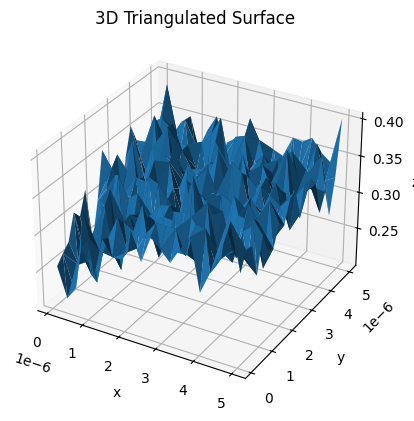

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

pts = [(*xy, z) for xy, z in average_data.items() if z is not None]
xs = np.array([p[0] for p in pts], dtype=float)
ys = np.array([p[1] for p in pts], dtype=float)
zs = np.array([p[2] for p in pts], dtype=float)

tri = mtri.Triangulation(xs, ys)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_trisurf(tri, zs, linewidth=0.2, antialiased=True)
ax.set_title("3D Triangulated Surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()